# Classification Automatique de Pathologies Cardiaques : Analyse Exploratoire et Interprétabilité
**Challenge ACDC - MICCAI 2017** Source : [https://www.creatis.insa-lyon.fr/Challenge/acdc/](https://www.creatis.insa-lyon.fr/Challenge/acdc/)
## 1. Contexte et Objectifs Cliniques

L'analyse de la fonction cardiaque par IRM (Cine-MRI) est le standard clinique pour évaluer l'état du myocarde et des ventricules. L'objectif de cette étude est de développer un pipeline d'apprentissage automatique capable de diagnostiquer automatiquement les patients parmi cinq classes cliniques :
* **NOR** : Sujets sains
* **MINF** : Infarctus du myocarde
* **DCM** : Cardiomyopathie dilatée
* **HCM** : Cardiomyopathie hypertrophique
* **RV** : Anomalie du ventricule droit

**L'enjeu méthodologique** : En imagerie médicale, un modèle performant ("boîte noire") n'est pas suffisant pour une intégration en routine clinique. Il est impératif que les prédictions soient explicables et reposent sur des critères physiologiques cohérents. Notre démarche consistera donc à extraire des descripteurs géométriques pertinents (radiomique), à valider rigoureusement un modèle linéaire, et à démontrer son interprétabilité.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.data_processing import parse_info_files, build_final_dataset
from src.extraction import extract_surfaces
from src.modeling import evaluate_model_cv, plot_shap_summary

sns.set_theme(style="whitegrid")
tcolor = [[153/255, 255/255, 102/255], [127/255, 185/255, 225/255], 
          [255/255, 124/255, 128/255], [255/255, 174/255, 101/255], 
          [168/255, 120/255, 110/255]]

## 2. Chargement du Jeu de Données Consolidé

Le script d'orchestration (`main.py`) a préalablement extrait les métadonnées cliniques et utilisé la librairie `pyradiomics` pour calculer les surfaces des régions d'intérêt (Ventricule Gauche, Ventricule Droit, Myocarde) à partir des segmentations NIfTI. Ces extractions ont été réalisées pour deux phases critiques du cycle cardiaque : la fin de la diastole (ED) et la fin de la systole (ES).

Nous chargeons ici le résultat de cette fusion pour l'analyse.

In [2]:
df_final = pd.read_csv('../data/dataset_complet_patients.csv')
df_final.head()

,Patient_ID,ED,ES,Group,Height,NbFrame,Weight,SurfaceArea_1_ED,SurfaceArea_1_ES,SurfaceArea_2_ED,SurfaceArea_2_ES,SurfaceArea_3_ED,SurfaceArea_3_ES
0,patient001,1,12,DCM,184.0,30,95.0,24379.399881,13890.170959,52224.277240,50032.251076,26493.225915,22542.509561
1,patient002,1,12,DCM,160.0,30,70.0,18517.602001,11124.520042,53267.670660,49017.949931,25966.690630,21079.218183
2,patient003,1,15,DCM,165.0,30,77.0,27127.476620,26673.658694,56194.401487,53996.918030,26076.832262,23961.490883
3,patient004,1,15,DCM,159.0,28,46.0,20729.818016,19920.735155,51149.899149,50359.053156,24905.586567,23029.507544
4,patient005,1,13,DCM,165.0,30,77.0,27985.069124,17614.444338,56917.666346,52623.860346,27599.235803,22824.444329


## 3. Analyse Exploratoire : Les limites des données macroscopiques

Avant d'utiliser des features extraites par imagerie, il est légitime de se demander si des caractéristiques physiologiques simples, telles que la taille et le poids du patient, pourraient suffire à distinguer certaines pathologies (par exemple, identifier une corrélation entre la corpulence et la cardiomyopathie dilatée).

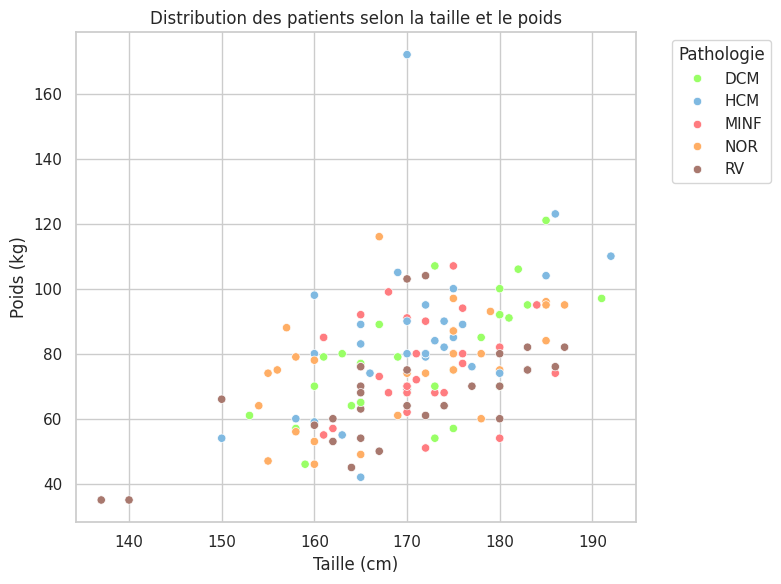

In [3]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_final, x='Height', y='Weight', hue='Group', palette=tcolor)
plt.title("Distribution des patients selon la taille et le poids")
plt.xlabel("Taille (cm)")
plt.ylabel("Poids (kg)")
plt.legend(title='Pathologie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

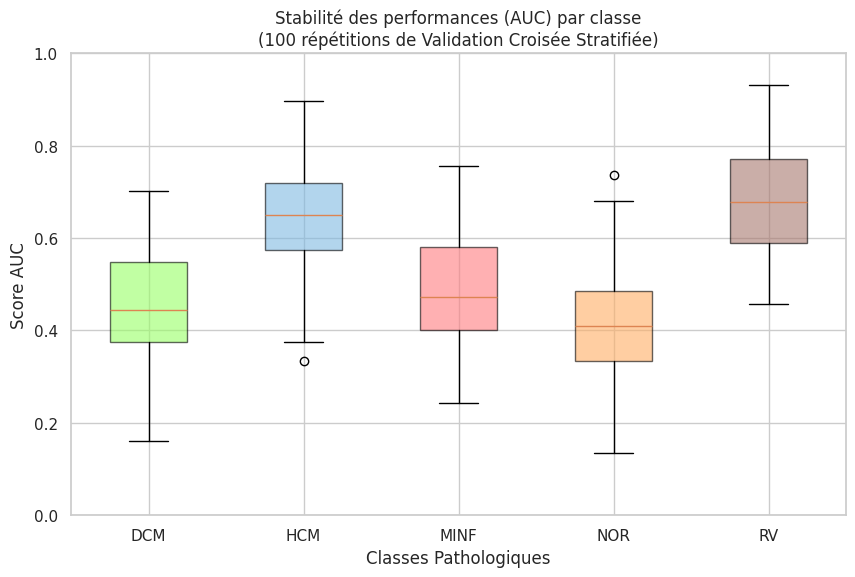

In [4]:
feature_cols = [
    'Height', 'Weight'
]
X = df_final[feature_cols]
y = df_final['Group']

auc_scores = evaluate_model_cv(X, y, n_splits=100)
classes = list(auc_scores.keys())
scores_list = [auc_scores[c] for c in classes]

plt.figure(figsize=(10, 6))
box = plt.boxplot(scores_list, labels=classes, patch_artist=True)

for patch, color in zip(box['boxes'], tcolor[:len(classes)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.title("Stabilité des performances (AUC) par classe\n(100 répétitions de Validation Croisée Stratifiée)")
plt.ylabel("Score AUC")
plt.xlabel("Classes Pathologiques")
plt.ylim(0.0, 1.0)
plt.show()

**Observation :** Comme l'illustre la figure ci-dessus, les classes pathologiques sont complètement intriquées. La taille et le poids seuls ne possèdent pas de pouvoir discriminant suffisant pour établir un diagnostic. L'extraction de biomarqueurs d'imagerie (tels que la géométrie des ventricules et du myocarde en dynamique systole/diastole) est donc une étape indispensable pour capturer la signature de ces pathologies.

## 4. Modélisation et Évaluation Robuste

Pour la modélisation, nous privilégions une **Régression Logistique**. Face à un jeu de données de taille restreinte (typique en imagerie médicale), un modèle linéaire fortement régularisé limite les risques de surapprentissage tout en offrant une transparence mathématique native.

Afin de garantir la capacité de généralisation du modèle et d'évaluer la stabilité de ses prédictions, nous appliquons une validation croisée répétée (*Stratified Shuffle Split*) avec 100 itérations. La métrique retenue est l'Aire sous la Courbe ROC (AUC), qui permet d'évaluer la capacité du modèle à discriminer chaque classe indépendamment des déséquilibres potentiels.

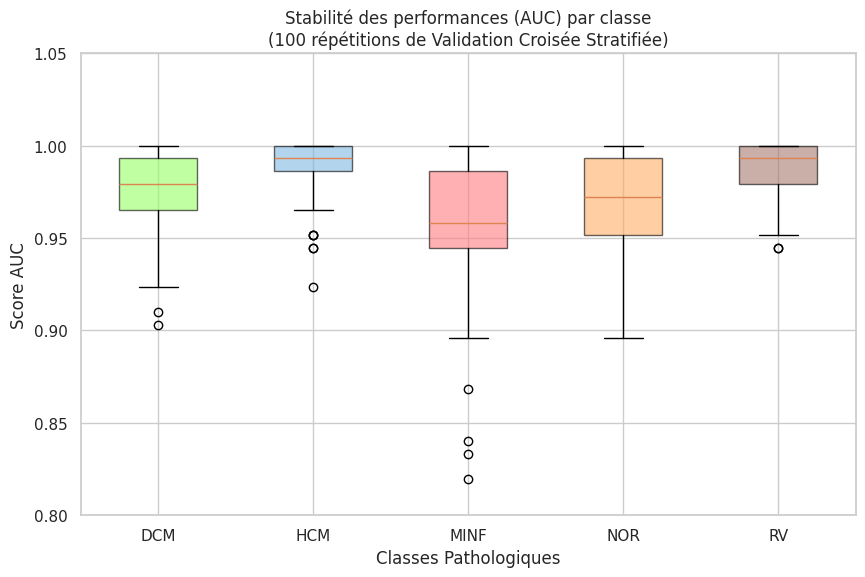

In [5]:
feature_cols = [
    'Height', 'Weight', 
    'SurfaceArea_1_ED', 'SurfaceArea_1_ES', 
    'SurfaceArea_2_ED', 'SurfaceArea_2_ES', 
    'SurfaceArea_3_ED', 'SurfaceArea_3_ES'
]
X = df_final[feature_cols]
y = df_final['Group']

auc_scores = evaluate_model_cv(X, y, n_splits=100)
classes = list(auc_scores.keys())
scores_list = [auc_scores[c] for c in classes]

plt.figure(figsize=(10, 6))
box = plt.boxplot(scores_list, labels=classes, patch_artist=True)

for patch, color in zip(box['boxes'], tcolor[:len(classes)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.title("Stabilité des performances (AUC) par classe\n(100 répétitions de Validation Croisée Stratifiée)")
plt.ylabel("Score AUC")
plt.xlabel("Classes Pathologiques")
plt.ylim(0.8, 1.05) 
plt.show()

**Analyse des performances :**
Les résultats démontrent une excellente capacité de discrimination du modèle :
* **HCM (0.99) et RV (0.99)** : Les cardiomyopathies hypertrophiques et les anomalies du ventricule droit sont presque parfaitement isolées, ce qui est cohérent avec la forte signature géométrique de ces maladies (épaississement marqué du myocarde ou dilatation extrême du VD).
* **DCM (0.97) et NOR (0.96)** : Le modèle parvient à identifier très efficacement les patients sains et ceux atteints de cardiomyopathie dilatée.
* **MINF (0.95)** : La discrimination de l'infarctus du myocarde présente une variance légèrement supérieure. Cela s'explique cliniquement : contrairement à la DCM qui modifie globalement la géométrie, le MINF implique souvent un défaut de contraction locale, un signal plus subtil à capturer via de simples mesures de surfaces globales.

## 5. Explicabilité Clinique (SHAP)

La validation d'un modèle médical exige de comprendre la mécanique de sa décision. Nous utilisons l'approche des valeurs de Shapley (SHAP - SHapley Additive exPlanations) pour quantifier la contribution marginale de chaque variable radiomique à la prédiction des différentes pathologies.

L'objectif est de vérifier si le modèle a appris des heuristiques cliniquement valides, ou s'il s'appuie sur des corrélations fortuites.

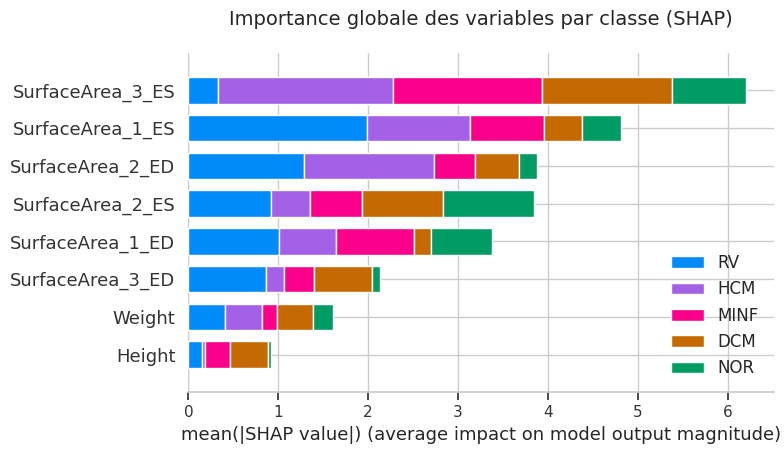

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
plot_shap_summary(X_train, X_test, y_train)

**Conclusion de l'analyse SHAP :**

L'analyse de l'importance des variables confirme la pertinence clinique du modèle :
1. **La dominance du Ventricule Gauche en fin de Systole (LV_ES)** : La surface du VG en fin de systole est le prédicteur principal pour la quasi-totalité des classes. Ceci est en parfaite adéquation avec la littérature médicale, puisque le volume télésystolique est le déterminant majeur de la fraction d'éjection (FE), l'indice clinique de référence pour évaluer la fonction cardiaque.
2. **La spécificité du Ventricule Droit** : Conformément à la logique anatomique, la prédiction de la classe `RV` (Abnormal Right Ventricle) est très majoritairement pilotée par la surface du ventricule droit en fin de systole (`SurfaceArea_1_ES`).
3. **Le faible impact des données macroscopiques** : Le poids et la taille confirment leur rôle marginal dans la décision finale, le modèle concentrant son attention sur l'information extraite de l'IRM.

En associant l'extraction de variables radiomiques (pyradiomics) à une approche d'apprentissage automatique interprétable, nous démontrons qu'il est possible d'atteindre des performances proches des standards experts tout en maintenant une totale transparence sur les critères de décision physiologiques.